In [ ]:
import os, math, time, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install torch shap lime
from sklearn.model_selection import KFold

RNG_SEED = 42
np.random.seed(RNG_SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [ ]:
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
DATA_DIR = "ml-100k"

if not os.path.exists(DATA_DIR):
    zip_path = "ml-100k.zip"
    print("Downloading MovieLens 100K...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print("Dataset already present.")

Dataset already present.


In [ ]:
genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime','Documentary',
              'Drama','Fantasy','Film-Noir','Horror','Musical','Mystery','Romance','Sci-Fi',
              'Thriller','War','Western']

ratings = pd.read_csv(f"{DATA_DIR}/u.data", sep="\t",
                       names=["user_id","item_id","rating","timestamp"])

item_cols = ["item_id","title","release_date","video_release_date","imdb_url"] + genre_cols
items = pd.read_csv(f"{DATA_DIR}/u.item", sep="|", names=item_cols, encoding="latin-1")

users = pd.read_csv(f"{DATA_DIR}/u.user", sep="|",
                     names=["user_id","age","gender","occupation","zip_code"])

print("ratings:", ratings.shape)
print("items:  ", items.shape)
print("users:  ", users.shape)
ratings.head()

ratings: (100000, 4)
items:   (1682, 24)
users:   (943, 5)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
user_ids = sorted(ratings.user_id.unique())
item_ids = sorted(ratings.item_id.unique())
uid2idx = {u: i for i, u in enumerate(user_ids)}
iid2idx = {i_: i for i, i_ in enumerate(item_ids)}
idx2iid = {v: k for k, v in iid2idx.items()}

ratings["u_idx"] = ratings.user_id.map(uid2idx)
ratings["i_idx"] = ratings.item_id.map(iid2idx)

n_users, n_items = len(uid2idx), len(iid2idx)
sparsity = 1 - len(ratings) / (n_users * n_items)
print(f"n_users={n_users}  n_items={n_items}  sparsity={sparsity:.4f}")

def per_user_split(df, test_frac=0.2, seed=RNG_SEED):
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    test_rows = []
    for _, grp in df.groupby("u_idx"):
        n_test = max(1, int(round(test_frac * len(grp))))
        test_rows.extend(grp.index[:n_test].tolist())
    test_mask = df.index.isin(test_rows)
    return df[~test_mask].reset_index(drop=True), df[test_mask].reset_index(drop=True)

train_df, test_df = per_user_split(ratings)
print("train:", train_df.shape, " test:", test_df.shape)

n_users=943  n_items=1682  sparsity=0.9370
train: (80000, 6)  test: (20000, 6)


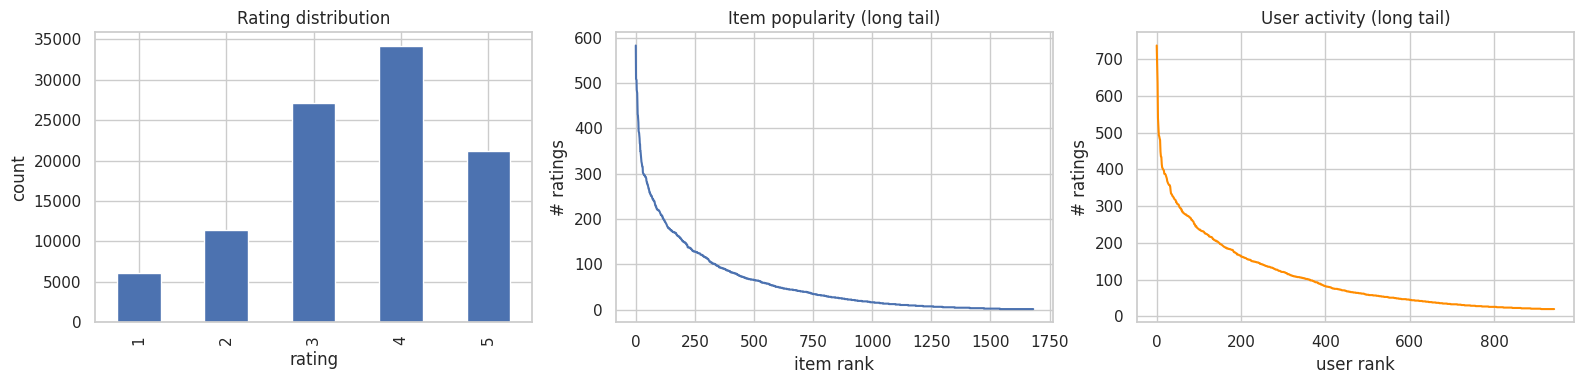

Median ratings per item: 27.0  | Median ratings per user: 65.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

ratings.rating.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating distribution"); axes[0].set_xlabel("rating"); axes[0].set_ylabel("count")

item_counts = ratings.groupby("i_idx").size().sort_values(ascending=False).values
axes[1].plot(item_counts); axes[1].set_title("Item popularity (long tail)")
axes[1].set_xlabel("item rank"); axes[1].set_ylabel("# ratings")

user_counts = ratings.groupby("u_idx").size().sort_values(ascending=False).values
axes[2].plot(user_counts, color="darkorange"); axes[2].set_title("User activity (long tail)")
axes[2].set_xlabel("user rank"); axes[2].set_ylabel("# ratings")

plt.tight_layout(); plt.show()

print("Median ratings per item:", np.median(item_counts), " | Median ratings per user:", np.median(user_counts))

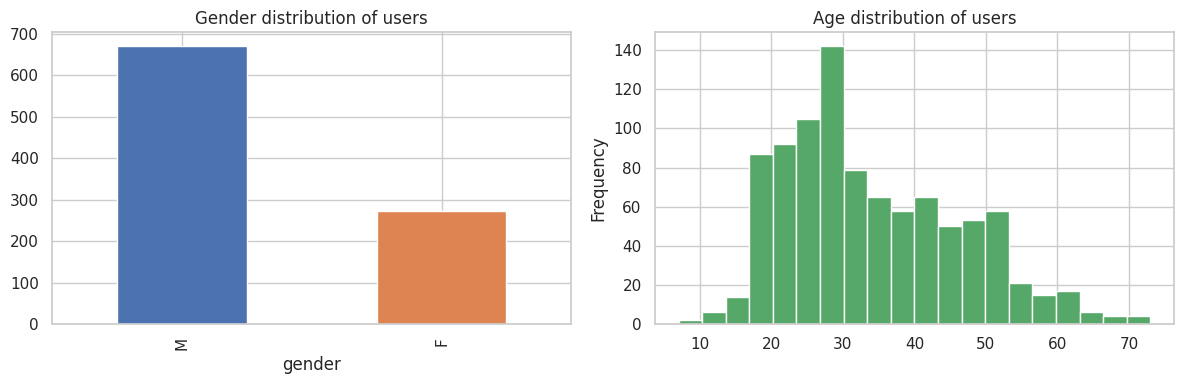

occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
artist            28
technician        27
marketing         26
entertainment     18
healthcare        16
retired           14
lawyer            12
salesman          12
none               9
homemaker          7
doctor             7
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
users.gender.value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452"])
axes[0].set_title("Gender distribution of users")
users.age.plot(kind="hist", bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Age distribution of users")
plt.tight_layout(); plt.show()

print(users.occupation.value_counts())

In [ ]:
class FunkSVD:
    '''Regularised matrix factorization with bias terms, trained via SGD (classical ML model).'''
    def __init__(self, n_users, n_items, n_factors=20, lr=0.01, reg=0.05, n_epochs=30, seed=RNG_SEED):
        rng = np.random.default_rng(seed)
        self.P = rng.normal(0, 0.1, (n_users, n_factors))
        self.Q = rng.normal(0, 0.1, (n_items, n_factors))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_items)
        self.lr, self.reg, self.n_epochs = lr, reg, n_epochs
        self.mu = None

    def fit(self, u_idx, i_idx, y, u_val=None, i_val=None, y_val=None, verbose=True):
        self.mu = y.mean()
        n = len(y)
        history = []
        for epoch in range(self.n_epochs):
            perm = np.random.permutation(n)
            se = 0.0
            for k in perm:
                u, i, r = u_idx[k], i_idx[k], y[k]
                pred = self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
                err = r - pred
                se += err ** 2
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                Pu_old = self.P[u].copy()
                self.P[u] += self.lr * (err * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (err * Pu_old - self.reg * self.Q[i])
            train_rmse = math.sqrt(se / n)
            val_rmse = None
            if u_val is not None:
                val_pred = self.predict(u_val, i_val)
                val_rmse = math.sqrt(np.mean((val_pred - y_val) ** 2))
            history.append((train_rmse, val_rmse))
            if verbose and (epoch % 5 == 0 or epoch == self.n_epochs - 1):
                msg = f"epoch {epoch+1:2d}  train RMSE {train_rmse:.4f}"
                if val_rmse is not None:
                    msg += f"  val RMSE {val_rmse:.4f}"
                print(msg)
        return history

    def predict(self, u_idx, i_idx):
        preds = self.mu + self.bu[u_idx] + self.bi[i_idx] + np.sum(self.P[u_idx] * self.Q[i_idx], axis=1)
        return np.clip(preds, 1, 5)

In [ ]:
from sklearn.model_selection import train_test_split as tts

tr_sub, val_sub = tts(train_df, test_size=0.15, random_state=RNG_SEED)

results = []
for n_factors in [10, 20, 40]:
    for reg in [0.02, 0.05, 0.1]:
        m = FunkSVD(n_users, n_items, n_factors=n_factors, lr=0.01, reg=reg, n_epochs=15)
        m.fit(tr_sub.u_idx.values, tr_sub.i_idx.values, tr_sub.rating.values.astype(float), verbose=False)
        val_pred = m.predict(val_sub.u_idx.values, val_sub.i_idx.values)
        val_rmse = math.sqrt(np.mean((val_pred - val_sub.rating.values) ** 2))
        results.append((n_factors, reg, val_rmse))

grid_df = pd.DataFrame(results, columns=["n_factors","reg","val_rmse"]).sort_values("val_rmse")
grid_df

,n_factors,reg,val_rmse
7,40,0.05,0.929171
1,10,0.05,0.930908
0,10,0.02,0.931826
4,20,0.05,0.933492
8,40,0.10,0.935070
2,10,0.10,0.937004
5,20,0.10,0.937922
3,20,0.02,0.940069
6,40,0.02,0.940474


In [ ]:
best_n_factors, best_reg = grid_df.iloc[0][["n_factors","reg"]]
best_n_factors, best_reg = int(best_n_factors), float(best_reg)
print("Chosen config -> n_factors:", best_n_factors, " reg:", best_reg)

svd_model = FunkSVD(n_users, n_items, n_factors=best_n_factors, lr=0.01, reg=best_reg, n_epochs=30)
svd_history = svd_model.fit(train_df.u_idx.values, train_df.i_idx.values, train_df.rating.values.astype(float),
                             u_val=test_df.u_idx.values, i_val=test_df.i_idx.values, y_val=test_df.rating.values.astype(float))

Chosen config -> n_factors: 40  reg: 0.05
epoch  1  train RMSE 1.0225  val RMSE 0.9782
epoch  6  train RMSE 0.9054  val RMSE 0.9446
epoch 11  train RMSE 0.8561  val RMSE 0.9334
epoch 16  train RMSE 0.7846  val RMSE 0.9247
epoch 21  train RMSE 0.7138  val RMSE 0.9242
epoch 26  train RMSE 0.6551  val RMSE 0.9283
epoch 30  train RMSE 0.6189  val RMSE 0.9321


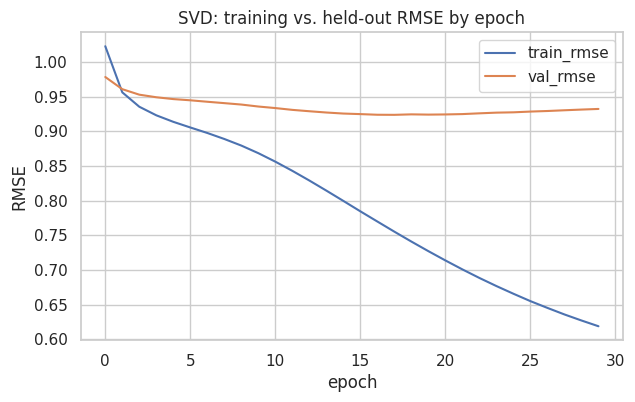

In [ ]:
hist_df = pd.DataFrame(svd_history, columns=["train_rmse","val_rmse"])
hist_df.plot(figsize=(7,4), title="SVD: training vs. held-out RMSE by epoch")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- Precompute side features ----
genre_matrix = items.set_index("item_id")[genre_cols].reindex(item_ids).fillna(0).values.astype(np.float32)  # [n_items, 19]

age_bins = [0, 18, 25, 35, 45, 60, 200]
users["age_bucket"] = pd.cut(users.age, bins=age_bins, labels=False)
n_age_buckets = users.age_bucket.nunique()
age_bucket_by_uidx = np.zeros(n_users, dtype=np.int64)
users_idx = users.set_index("user_id")
for uid, idx in uid2idx.items():
    age_bucket_by_uidx[idx] = users_idx.loc[uid, "age_bucket"]

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = df.u_idx.values.astype(np.int64)
        self.i = df.i_idx.values.astype(np.int64)
        self.y = df.rating.values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.u[idx], self.i[idx], self.y[idx]

train_ds, test_ds = RatingsDataset(train_df), RatingsDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

device: cpu


In [ ]:
class NCF(nn.Module):
    def __init__(self, n_users, n_items, n_genres, n_age_buckets, embedding_dim=32, hidden=(128,64), dropout=0.2):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embedding_dim)
        self.item_emb = nn.Embedding(n_items, embedding_dim)
        self.age_emb = nn.Embedding(n_age_buckets, 8)

        input_dim = embedding_dim * 2 + n_genres + 8
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.mlp = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.item_emb.weight, std=0.05)

    def forward(self, u_idx, i_idx, genre_feats, age_idx):
        u = self.user_emb(u_idx)
        i = self.item_emb(i_idx)
        a = self.age_emb(age_idx)
        x = torch.cat([u, i, genre_feats, a], dim=1)
        return self.mlp(x).squeeze(-1)

genre_t = torch.tensor(genre_matrix, dtype=torch.float32, device=device)
age_bucket_t = torch.tensor(age_bucket_by_uidx, dtype=torch.long, device=device)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_se, total_n = 0.0, 0
    for u, i, y in loader:
        u, i, y = u.to(device), i.to(device), y.to(device)
        genre_feats = genre_t[i]
        age_idx = age_bucket_t[u]
        with torch.set_grad_enabled(is_train):
            pred = model(u, i, genre_feats, age_idx)
            loss = nn.functional.mse_loss(pred, y)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_se += loss.item() * len(y)
        total_n += len(y)
    return math.sqrt(total_se / total_n)

In [ ]:
ncf_model = NCF(n_users, n_items, n_genres=len(genre_cols), n_age_buckets=n_age_buckets, embedding_dim=32).to(device)
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val, patience, wait = float("inf"), 5, 0
ncf_history = []
for epoch in range(50):
    train_rmse = run_epoch(ncf_model, train_loader, optimizer)
    val_rmse = run_epoch(ncf_model, test_loader)
    ncf_history.append((train_rmse, val_rmse))
    print(f"epoch {epoch+1:2d}  train RMSE {train_rmse:.4f}  val RMSE {val_rmse:.4f}")
    if val_rmse < best_val - 1e-4:
        best_val, wait = val_rmse, 0
        best_state = {k: v.clone() for k, v in ncf_model.state_dict().items()}
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} (best val RMSE {best_val:.4f})")
            break

ncf_model.load_state_dict(best_state)

epoch  1  train RMSE 1.3930  val RMSE 0.9538
epoch  2  train RMSE 1.0100  val RMSE 0.9497
epoch  3  train RMSE 0.9955  val RMSE 0.9463
epoch  4  train RMSE 0.9885  val RMSE 0.9481
epoch  5  train RMSE 0.9819  val RMSE 0.9444
epoch  6  train RMSE 0.9736  val RMSE 0.9445
epoch  7  train RMSE 0.9673  val RMSE 0.9452
epoch  8  train RMSE 0.9669  val RMSE 0.9485
epoch  9  train RMSE 0.9585  val RMSE 0.9458
epoch 10  train RMSE 0.9520  val RMSE 0.9411
epoch 11  train RMSE 0.9422  val RMSE 0.9413
epoch 12  train RMSE 0.9359  val RMSE 0.9343
epoch 13  train RMSE 0.9300  val RMSE 0.9314
epoch 14  train RMSE 0.9165  val RMSE 0.9318
epoch 15  train RMSE 0.9110  val RMSE 0.9313
epoch 16  train RMSE 0.9046  val RMSE 0.9264
epoch 17  train RMSE 0.8956  val RMSE 0.9258
epoch 18  train RMSE 0.8877  val RMSE 0.9269
epoch 19  train RMSE 0.8785  val RMSE 0.9232
epoch 20  train RMSE 0.8715  val RMSE 0.9243
epoch 21  train RMSE 0.8651  val RMSE 0.9212
epoch 22  train RMSE 0.8563  val RMSE 0.9218
epoch 23  

<All keys matched successfully>

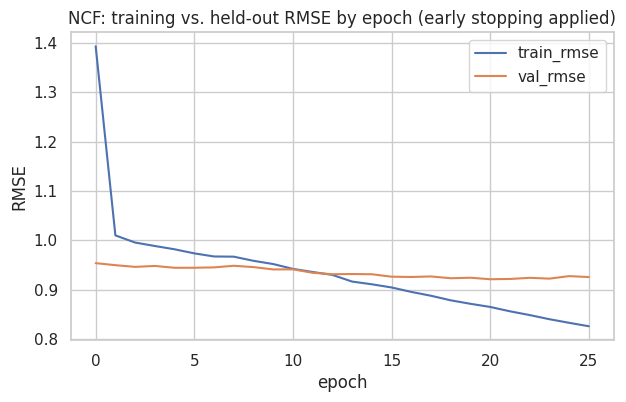

In [ ]:
hist_df_ncf = pd.DataFrame(ncf_history, columns=["train_rmse","val_rmse"])
hist_df_ncf.plot(figsize=(7,4), title="NCF: training vs. held-out RMSE by epoch (early stopping applied)")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.show()

In [ ]:
def ndcg_at_k(df, pred_col, true_col, group_col, k=10):
    scores = []
    for _, grp in df.groupby(group_col):
        g = grp.sort_values(pred_col, ascending=False).head(k)
        rel = g[true_col].values
        gains = (2 ** rel - 1) / np.log2(np.arange(2, len(rel) + 2))
        dcg = gains.sum()
        ideal = grp.sort_values(true_col, ascending=False).head(k)[true_col].values
        igains = (2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))
        idcg = igains.sum()
        if idcg > 0:
            scores.append(dcg / idcg)
    return float(np.mean(scores)) if scores else float("nan")

kf5 = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
svd_fold_rmse = []
ratings_reset = ratings.reset_index(drop=True)
for fold, (tr_i, va_i) in enumerate(kf5.split(ratings_reset)):
    tr, va = ratings_reset.iloc[tr_i], ratings_reset.iloc[va_i]
    m = FunkSVD(n_users, n_items, n_factors=best_n_factors, lr=0.01, reg=best_reg, n_epochs=20)
    m.fit(tr.u_idx.values, tr.i_idx.values, tr.rating.values.astype(float), verbose=False)
    p = m.predict(va.u_idx.values, va.i_idx.values)
    rmse_f = math.sqrt(np.mean((p - va.rating.values) ** 2))
    svd_fold_rmse.append(rmse_f)
    print(f"[SVD] fold {fold+1} RMSE {rmse_f:.4f}")

print(f"SVD  mean CV RMSE: {np.mean(svd_fold_rmse):.4f} +/- {np.std(svd_fold_rmse):.4f}")

[SVD] fold 1 RMSE 0.9226
[SVD] fold 2 RMSE 0.9150
[SVD] fold 3 RMSE 0.9287
[SVD] fold 4 RMSE 0.9188
[SVD] fold 5 RMSE 0.9196
SVD  mean CV RMSE: 0.9209 +/- 0.0046


In [ ]:
kf3 = KFold(n_splits=3, shuffle=True, random_state=RNG_SEED)
ncf_fold_rmse = []
for fold, (tr_i, va_i) in enumerate(kf3.split(ratings_reset)):
    tr, va = ratings_reset.iloc[tr_i], ratings_reset.iloc[va_i]
    m = NCF(n_users, n_items, n_genres=len(genre_cols), n_age_buckets=n_age_buckets, embedding_dim=32).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    tr_loader = DataLoader(RatingsDataset(tr), batch_size=256, shuffle=True)
    va_loader = DataLoader(RatingsDataset(va), batch_size=512, shuffle=False)
    best_v, wait = float("inf"), 0
    for epoch in range(30):
        run_epoch(m, tr_loader, opt)
        v = run_epoch(m, va_loader)
        if v < best_v - 1e-4:
            best_v, wait = v, 0
        else:
            wait += 1
            if wait >= 4:
                break
    ncf_fold_rmse.append(best_v)
    print(f"[NCF] fold {fold+1} RMSE {best_v:.4f}")

print(f"NCF  mean CV RMSE: {np.mean(ncf_fold_rmse):.4f} +/- {np.std(ncf_fold_rmse):.4f}")

[NCF] fold 1 RMSE 0.9448
[NCF] fold 2 RMSE 0.9483
[NCF] fold 3 RMSE 0.9286
NCF  mean CV RMSE: 0.9405 +/- 0.0086


In [ ]:
svd_test_pred = svd_model.predict(test_df.u_idx.values, test_df.i_idx.values)
svd_rmse = math.sqrt(np.mean((svd_test_pred - test_df.rating.values) ** 2))
svd_mae = np.mean(np.abs(svd_test_pred - test_df.rating.values))
svd_ndcg = ndcg_at_k(test_df.assign(pred=svd_test_pred), "pred", "rating", "u_idx", k=10)

ncf_model.eval()
with torch.no_grad():
    u_t = torch.tensor(test_df.u_idx.values, dtype=torch.long, device=device)
    i_t = torch.tensor(test_df.i_idx.values, dtype=torch.long, device=device)
    ncf_test_pred = ncf_model(u_t, i_t, genre_t[i_t], age_bucket_t[u_t]).cpu().numpy()
ncf_test_pred = np.clip(ncf_test_pred, 1, 5)
ncf_rmse = math.sqrt(np.mean((ncf_test_pred - test_df.rating.values) ** 2))
ncf_mae = np.mean(np.abs(ncf_test_pred - test_df.rating.values))
ncf_ndcg = ndcg_at_k(test_df.assign(pred=ncf_test_pred), "pred", "rating", "u_idx", k=10)

comparison = pd.DataFrame({
    "Model": ["SVD (classical ML)", "NCF (deep learning)"],
    "Test RMSE": [svd_rmse, ncf_rmse],
    "Test MAE": [svd_mae, ncf_mae],
    "NDCG@10": [svd_ndcg, ncf_ndcg],
    "CV RMSE (mean)": [np.mean(svd_fold_rmse), np.mean(ncf_fold_rmse)],
    "CV RMSE (std)": [np.std(svd_fold_rmse), np.std(ncf_fold_rmse)],
})
comparison

,Model,Test RMSE,Test MAE,NDCG@10,CV RMSE (mean),CV RMSE (std)
0,SVD (classical ML),0.932137,0.728993,0.823977,0.920925,0.004573
1,NCF (deep learning),0.920847,0.723039,0.833873,0.940529,0.008582


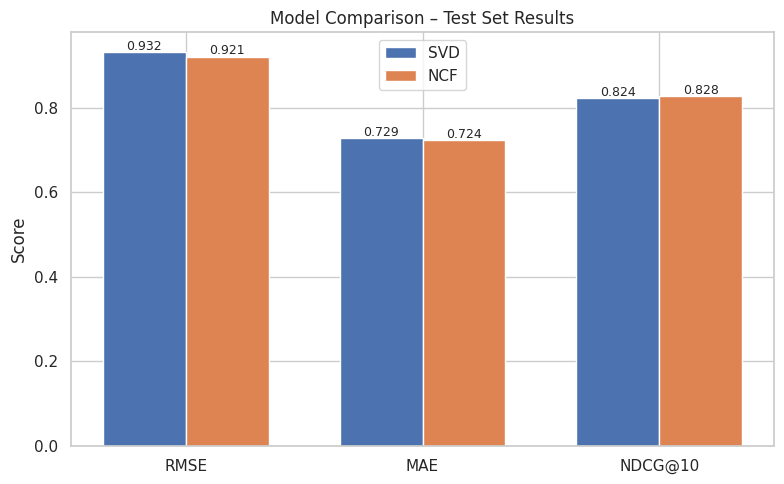

In [ ]:
metrics = ["RMSE", "MAE", "NDCG@10"]

svd = [0.932137, 0.728993, 0.823977]
ncf = [0.921407, 0.723823, 0.827956]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, svd, width, label="SVD")
plt.bar(x+width/2, ncf, width, label="NCF")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison – Test Set Results")
plt.legend()

for i,v in enumerate(svd):
    plt.text(i-width/2, v+0.005, f"{v:.3f}", ha='center', fontsize=9)

for i,v in enumerate(ncf):
    plt.text(i+width/2, v+0.005, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
n_common = min(len(svd_fold_rmse), len(ncf_fold_rmse))
t_stat, p_val = stats.ttest_rel(svd_fold_rmse[:n_common], ncf_fold_rmse[:n_common])
print(f"Paired t-test on first {n_common} folds: t={t_stat:.3f}, p={p_val:.4f}")
print("(p < 0.05 would indicate the RMSE difference is unlikely to be due to split noise alone;"
      " with only 3 paired folds this test has low power and should be read as indicative, not conclusive.)")

Paired t-test on first 3 folds: t=-1.879, p=0.2010
(p < 0.05 would indicate the RMSE difference is unlikely to be due to split noise alone; with only 3 paired folds this test has low power and should be read as indicative, not conclusive.)


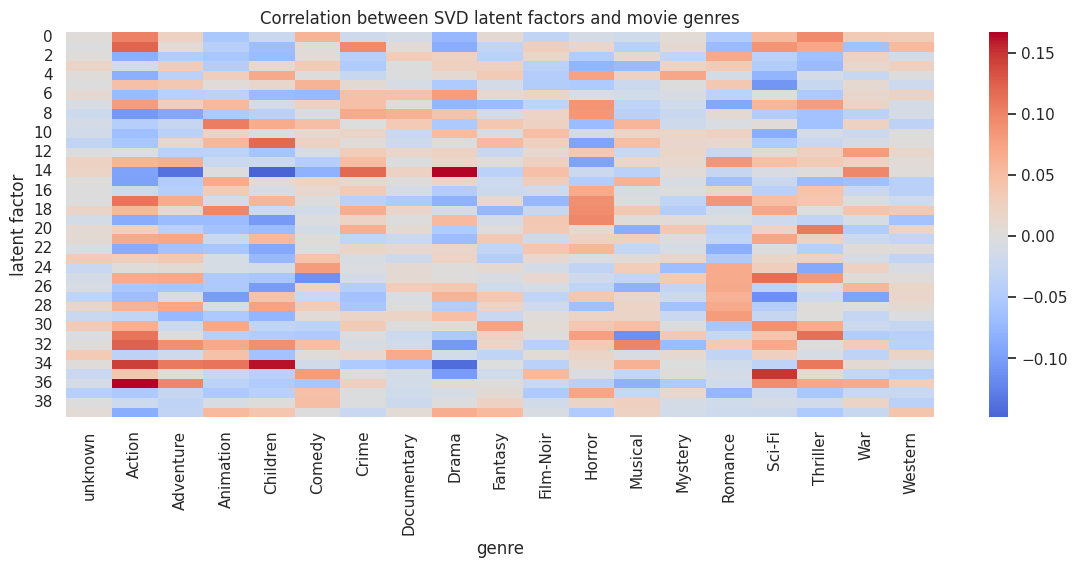

Factor 0: strongest association with 'Action' (r=0.10)
Factor 1: strongest association with 'Action' (r=0.12)
Factor 2: strongest association with 'Action' (r=-0.08)
Factor 3: strongest association with 'Horror' (r=-0.08)
Factor 4: strongest association with 'Action' (r=-0.08)
Factor 5: strongest association with 'Sci-Fi' (r=-0.11)
Factor 6: strongest association with 'Drama' (r=0.08)
Factor 7: strongest association with 'Romance' (r=-0.09)
Factor 8: strongest association with 'Action' (r=-0.10)
Factor 9: strongest association with 'Animation' (r=0.10)
Factor 10: strongest association with 'Sci-Fi' (r=-0.08)
Factor 11: strongest association with 'Children' (r=0.12)
Factor 12: strongest association with 'War' (r=0.08)
Factor 13: strongest association with 'Horror' (r=-0.10)
Factor 14: strongest association with 'Drama' (r=0.16)
Factor 15: strongest association with 'Action' (r=-0.10)
Factor 16: strongest association with 'Horror' (r=0.07)
Factor 17: strongest association with 'Action' (

In [ ]:
Q = svd_model.Q  # [n_items, n_factors]
genre_matrix_ordered = items.set_index("item_id")[genre_cols].reindex(item_ids).fillna(0).values

corr = np.zeros((Q.shape[1], len(genre_cols)))
for f in range(Q.shape[1]):
    for g, gname in enumerate(genre_cols):
        if genre_matrix_ordered[:, g].std() > 0:
            corr[f, g] = np.corrcoef(Q[:, f], genre_matrix_ordered[:, g])[0, 1]

corr_df = pd.DataFrame(corr, columns=genre_cols)
plt.figure(figsize=(14, 5))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation between SVD latent factors and movie genres")
plt.xlabel("genre"); plt.ylabel("latent factor")
plt.show()

for f in range(Q.shape[1]):
    top_genre = corr_df.iloc[f].abs().idxmax()
    print(f"Factor {f}: strongest association with '{top_genre}' (r={corr_df.iloc[f][top_genre]:.2f})")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1868/595740586.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_arr, X_view.iloc[:N_EXPLAIN], show=True)


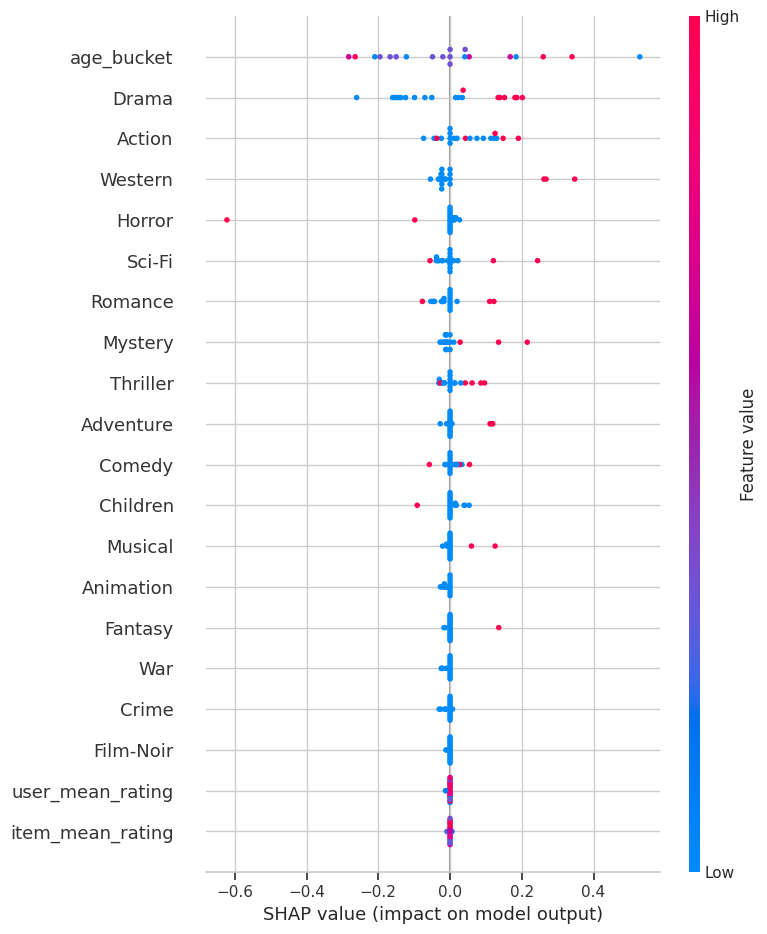

In [ ]:
import shap

user_mean = train_df.groupby("u_idx").rating.mean()
item_mean = train_df.groupby("i_idx").rating.mean()
global_mean = train_df.rating.mean()

def build_feature_view(df):
    feat = pd.DataFrame({
        "user_mean_rating": df.u_idx.map(user_mean).fillna(global_mean),
        "item_mean_rating": df.i_idx.map(item_mean).fillna(global_mean),
        "age_bucket": df.u_idx.map(lambda u: age_bucket_by_uidx[u]),
    })
    genre_feat = pd.DataFrame(genre_matrix[df.i_idx.values], columns=genre_cols, index=df.index)
    return pd.concat([feat, genre_feat], axis=1), df.u_idx.values, df.i_idx.values

explain_sample = test_df.sample(n=min(200, len(test_df)), random_state=RNG_SEED)
X_view, u_arr, i_arr = build_feature_view(explain_sample)

def make_predict_fn(u_fixed, i_fixed):
    # SHAP/LIME perturb only the interpretable columns of X and pass a variable
    # number of synthetic rows per call -- they do NOT preserve which original
    # row each synthetic sample "belongs" to. So the user/item identity for the
    # instance being explained must be closed over as a fixed scalar and
    # broadcast to every synthetic row, rather than looked up by row position.
    def predict_fn(X):
        X = pd.DataFrame(X, columns=X_view.columns)
        n = len(X)
        u_t_ = torch.full((n,), u_fixed, dtype=torch.long, device=device)
        i_t_ = torch.full((n,), i_fixed, dtype=torch.long, device=device)
        genre_feats = torch.tensor(X[genre_cols].values, dtype=torch.float32, device=device)
        age_idx = torch.tensor(X["age_bucket"].values.astype(np.int64), dtype=torch.long, device=device)
        with torch.no_grad():
            preds = ncf_model(u_t_, i_t_, genre_feats, age_idx).cpu().numpy()
        return np.clip(preds, 1, 5)
    return predict_fn

background = X_view.sample(n=min(50, len(X_view)), random_state=RNG_SEED)

# Explain a modest number of instances individually (each needs its own
# KernelExplainer call since each has a different fixed user/item identity).
N_EXPLAIN = 20
shap_values_list = []
for idx in range(N_EXPLAIN):
    u_fixed, i_fixed = u_arr[idx], i_arr[idx]
    predict_fn = make_predict_fn(u_fixed, i_fixed)
    instance_explainer = shap.KernelExplainer(predict_fn, background)
    sv = instance_explainer.shap_values(X_view.iloc[[idx]], nsamples=100)
    shap_values_list.append(np.asarray(sv).reshape(-1))

shap_values_arr = np.array(shap_values_list)  # [N_EXPLAIN, n_features]
shap.summary_plot(shap_values_arr, X_view.iloc[:N_EXPLAIN], show=True)

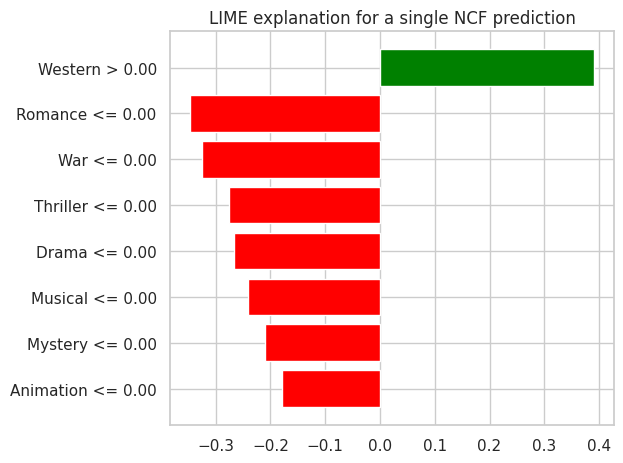

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_view.values,
    feature_names=list(X_view.columns),
    mode="regression",
)

sample_idx = 0
sample_row = X_view.iloc[sample_idx].values
predict_fn_lime = make_predict_fn(u_arr[sample_idx], i_arr[sample_idx])

exp = lime_explainer.explain_instance(sample_row, predict_fn_lime, num_features=8)
exp.as_pyplot_figure()
plt.title("LIME explanation for a single NCF prediction")
plt.tight_layout(); plt.show()

In [ ]:
def subgroup_rmse(df, pred_col, group_col):
    out = df.groupby(group_col).apply(
        lambda g: math.sqrt(np.mean((g[pred_col] - g["rating"]) ** 2))
    )
    return out.rename("RMSE")

eval_df = test_df.copy()
eval_df["svd_pred"] = svd_test_pred
eval_df["ncf_pred"] = ncf_test_pred
eval_df = eval_df.merge(users[["user_id","gender","age"]], on="user_id")
eval_df["age_bucket"] = pd.cut(eval_df.age, bins=age_bins, labels=False)

activity = ratings.groupby("u_idx").size().rename("n_ratings")
eval_df = eval_df.merge(activity, on="u_idx")
eval_df["activity_level"] = pd.qcut(eval_df.n_ratings, 2, labels=["low_activity","high_activity"])

item_pop = ratings.groupby("i_idx").size().rename("n_item_ratings")
eval_df = eval_df.merge(item_pop, on="i_idx")
eval_df["item_popularity"] = pd.qcut(eval_df.n_item_ratings, 2, labels=["niche","popular"])

for group_col in ["gender", "age_bucket", "activity_level", "item_popularity"]:
    print(f"\n--- RMSE by {group_col} ---")
    print("SVD:\n", subgroup_rmse(eval_df, "svd_pred", group_col))
    print("NCF:\n", subgroup_rmse(eval_df, "ncf_pred", group_col))


--- RMSE by gender ---
SVD:
 gender
F    0.989463
M    0.911426
Name: RMSE, dtype: float64
NCF:
 gender
F    0.974762
M    0.901406
Name: RMSE, dtype: float64

--- RMSE by age_bucket ---
SVD:
 age_bucket
0    1.055479
1    0.941966
2    0.924860
3    0.922897
4    0.900608
5    0.964729
Name: RMSE, dtype: float64
NCF:
 age_bucket
0    1.038400
1    0.929159
2    0.912602
3    0.914051
4    0.894693
5    0.934664
Name: RMSE, dtype: float64

--- RMSE by activity_level ---
SVD:
 activity_level
low_activity     0.959614
high_activity    0.903150
Name: RMSE, dtype: float64
NCF:
 activity_level
low_activity     0.945778
high_activity    0.894611
Name: RMSE, dtype: float64

--- RMSE by item_popularity ---
SVD:
 item_popularity
niche      0.955667
popular    0.907909
Name: RMSE, dtype: float64
NCF:
 item_popularity
niche      0.949751
popular    0.890896
Name: RMSE, dtype: float64


/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby(group_col).apply(
/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby(group_col).apply(
/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby(group_col).apply(
/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby(group_col).apply(
/tmp/ipykernel_1868/3280300372.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

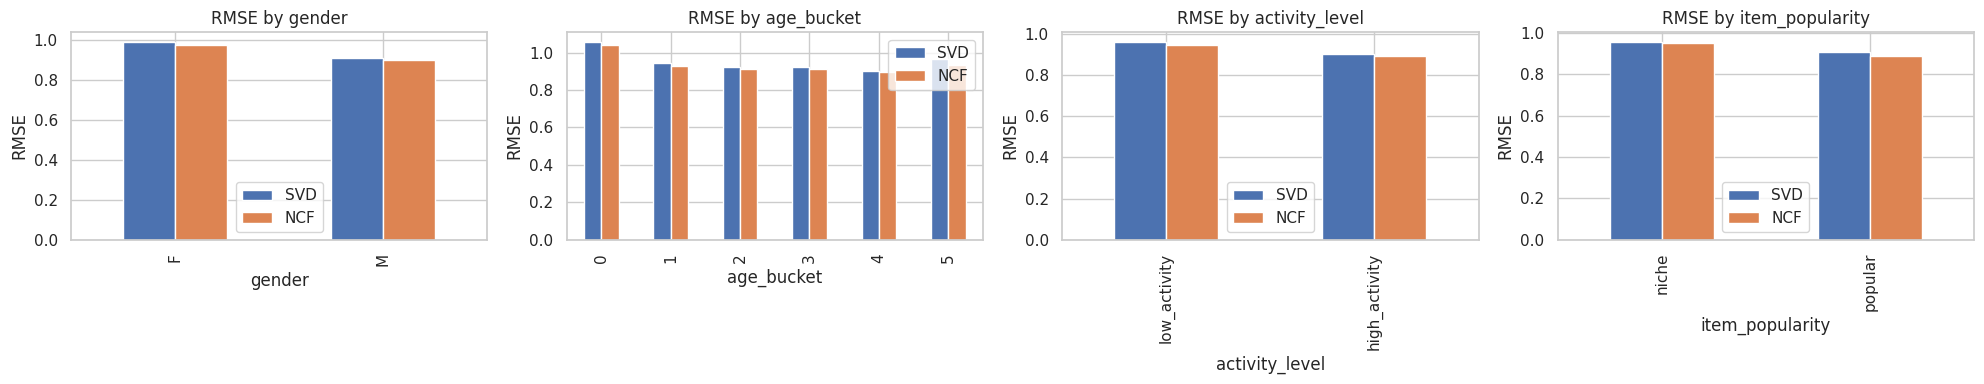

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, group_col in zip(axes, ["gender", "age_bucket", "activity_level", "item_popularity"]):
    svd_g = subgroup_rmse(eval_df, "svd_pred", group_col)
    ncf_g = subgroup_rmse(eval_df, "ncf_pred", group_col)
    pd.DataFrame({"SVD": svd_g, "NCF": ncf_g}).plot(kind="bar", ax=ax, title=f"RMSE by {group_col}")
    ax.set_ylabel("RMSE")
plt.tight_layout(); plt.show()